## Data loading

### Subtask:
Load the data from the "Volontaire" sheet of the "processed (1).xlsx" Excel file into a pandas DataFrame.


In [ ]:
import os

current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

sibling_dir = os.path.join(parent_dir, 'data', 'processed')
excel_file_path = os.path.join(sibling_dir, 'processed.xlsx')



True

In [5]:
# @title
import pandas as pd

try:
    df_volontaire = pd.read_excel(excel_file_path, sheet_name="Volontaire")
    display(df_volontaire.head())
    print(df_volontaire.columns)
except FileNotFoundError:
    print("Error: 'processed.xlsx' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

,ID,Age,Niveau_d'etude,Genre,Taille,Poids,Situation_Matrimoniale_(SM),Profession,Arrondissement_de_résidence,Quartier_de_Résidence,...,Raison_de_non-eligibilité_totale__[Asthmatiques],Raison_de_non-eligibilité_totale__[Cardiaque],Raison_de_non-eligibilité_totale__[Tatoué],Raison_de_non-eligibilité_totale__[Scarifié],IMC,Fréquence_de_don,Groupe_d'âge,Catégorie_d'IMC,Statut_d'éligibilité,Catégorie_de_niveau_d'hémoglobine
0,DONOR_1842,24,Universitaire,Homme,172.816667,77.278846,Célibataire,Etudiant (e),Douala 3,Yassa,...,Non,Non,Non,Non,25.88,0,18-25,Surpoids,1,Normal
1,DONOR_1843,23,Universitaire,Homme,172.816667,77.278846,Célibataire,Sans Emplois,R A S,R A S,...,Non,Non,Non,Non,25.88,1,18-25,Surpoids,0,Bas
2,DONOR_1844,41,Aucun,Homme,172.816667,77.278846,Marié (e),Tailleur,Douala 1,NEW BELL,...,Non,Non,Non,Non,25.88,0,36-45,Surpoids,0,Normal
3,DONOR_1845,24,Universitaire,Homme,172.816667,77.278846,Célibataire,Etudiant,Douala 5,Ange raphael,...,Non,Non,Non,Non,25.88,0,18-25,Surpoids,1,Normal
4,DONOR_1846,30,Secondaire,Homme,172.816667,77.278846,Célibataire,Militaire,Douala,Beedi,...,Non,Non,Non,Non,25.88,1,26-35,Surpoids,1,Normal


Index(['ID', 'Age', 'Niveau_d'etude', 'Genre', 'Taille', 'Poids',
       'Situation_Matrimoniale_(SM)', 'Profession',
       'Arrondissement_de_résidence', 'Quartier_de_Résidence', 'Nationalité',
       'Religion', 'A-t-il_(elle)_déjà_donné_le_sang', 'Taux_d’hémoglobine',
       'ÉLIGIBILITÉ_AU_DON',
       'Raison_indisponibilité__[Est_sous_anti-biothérapie__]',
       'Raison_indisponibilité__[Taux_d’hémoglobine_bas_]',
       'Raison_indisponibilité__[date_de_dernier_Don_<_3_mois_]',
       'Raison_indisponibilité__[IST_récente_(Exclu_VIH,_Hbs,_Hcv)]',
       'Raison_de_l’indisponibilité_de_la_femme_[La_DDR_est_mauvais_si_<14_jour_avant_le_don]',
       'Raison_de_l’indisponibilité_de_la_femme_[Allaitement_]',
       'Raison_de_l’indisponibilité_de_la_femme_[A_accoucher_ces_6_derniers_mois__]',
       'Raison_de_l’indisponibilité_de_la_femme_[Interruption_de_grossesse__ces_06_derniers_mois]',
       'Raison_de_l’indisponibilité_de_la_femme_[est_enceinte_]',
       'Raison_de_non-eli

## Data wrangling

### Subtask:
Prepare the data for modeling.




```
```

**Reasoning**:
Applying the `cluster_columns` function to create chronic and transmissible columns, select specified columns, handle

---

missing values, and perform one-hot encoding on the categorical features.



In [6]:
# @title
import pandas as pd
import random
from sklearn.preprocessing import OneHotEncoder

# column names
chronic_diseases = [
    'Raison_de_non-eligibilité_totale__[Diabétique]',
    'Raison_de_non-eligibilité_totale__[Hypertendus]',
    'Raison_de_non-eligibilité_totale__[Asthmatiques]',
    'Raison_de_non-eligibilité_totale__[Cardiaque]',
    'Raison_de_non-eligibilité_totale__[Drepanocytaire]'
]
transmissible_diseases = [
    'Raison_de_non-eligibilité_totale__[Porteur(HIV,hbs,hcv)]',
    'Raison_indisponibilité__[IST_récente_(Exclu_VIH,_Hbs,_Hcv)]'
]

def cluster_columns(sheet):
    sheet['chronic_diseases'] = sheet[chronic_diseases].apply(lambda row: 'Oui' if row.str.contains('Oui').any() else 'Non', axis=1)
    sheet['transmissible_diseases'] = sheet[transmissible_diseases].apply(lambda row: 'Oui' if row.str.contains('Oui').any() else 'Non', axis=1)
    test_column = random.choice(chronic_diseases)
    child_count = (sheet[test_column] == 'Oui').sum()
    grouped_count = (sheet['chronic_diseases'] == 'Oui').sum()
    #If any child's is `oui` then the parent group becomes `oui` . This assert ensures that
    assert child_count <= grouped_count, f"Test failed for {test_column}. Expected child count to be less than or equal to grouped count."
    print(f"Test passed for {test_column}. Child count: {child_count}, Grouped count: {grouped_count}")

# apply the function to the DataFrame
cluster_columns(df_volontaire)

# select columns
selected_columns = ['Age', 'Poids', 'Genre', 'Taille', 'chronic_diseases', 'transmissible_diseases', "Statut_d'éligibilité"]
df_model = df_volontaire[selected_columns].copy()
df_model.rename(columns={"Statut_d'éligibilité": 'is_eligible', "Age": "age", "Poids": "poids", "Genre": "genre", "Taille": "taille"}, inplace=True)

# handle missing values
df_model.dropna(inplace=True)

# one-hot encode categorical features
categorical_cols = ['genre', 'chronic_diseases', 'transmissible_diseases']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = ohe.fit_transform(df_model[categorical_cols])
encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(categorical_cols))
df_model = pd.concat([df_model.drop(categorical_cols, axis=1), encoded_df], axis=1)

display(df_model.head())

Test passed for Raison_de_non-eligibilité_totale__[Hypertendus]. Child count: 1, Grouped count: 12


,age,poids,taille,is_eligible,genre_Femme,genre_Homme,chronic_diseases_Non,chronic_diseases_Oui,transmissible_diseases_Non,transmissible_diseases_Oui
0,24,77.278846,172.816667,1,0.0,1.0,1.0,0.0,1.0,0.0
1,23,77.278846,172.816667,0,0.0,1.0,1.0,0.0,1.0,0.0
2,41,77.278846,172.816667,0,0.0,1.0,1.0,0.0,1.0,0.0
3,24,77.278846,172.816667,1,0.0,1.0,1.0,0.0,1.0,0.0
4,30,77.278846,172.816667,1,0.0,1.0,1.0,0.0,1.0,0.0


## Data splitting

### Subtask:
Splitting the prepared data into training and testing sets.


In [7]:
# @title
from sklearn.model_selection import train_test_split

# Defining features (X) and target (y)
X = df_model.drop('is_eligible', axis=1)
y = df_model['is_eligible']

# Spliting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#verifying the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1476, 9)
X_test shape: (370, 9)
y_train shape: (1476,)
y_test shape: (370,)


## Data preparation

### Subtask:
Applying SMOTE to the training data (`X_train`, `y_train`) to address class imbalance.


In [8]:
# @title
from imblearn.over_sampling import SMOTE
import numpy as np

# Apply SMOTE to the training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

X_train_resampled = np.array(X_train_resampled)
y_train_resampled = np.array(y_train_resampled)

print("X_train_resampled shape:", X_train_resampled.shape)
print("y_train_resampled shape:", y_train_resampled.shape)

ModuleNotFoundError: No module named 'imblearn'

## Model training

### Subtask:
Train a Random Forest Classifier on the SMOTE-resampled training data.


**Reasoning**:
Train a Random Forest Classifier on the SMOTE-resampled training data.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

## Model optimization

### Subtask:
Optimizing the hyperparameters of the RandomForestClassifier using RandomizedSearchCV to maximize AUC-ROC.


In [ ]:
# @title
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier

# parameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': uniform(0.1, 0.9),
}

# Initializing....
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    random_state=42,
)

# Training
random_search.fit(X_train_resampled, y_train_resampled)

print("Best Hyperparameters:", random_search.best_params_)
print("Best AUC-ROC Score:", random_search.best_score_)

# Storing best Estimator
best_rf_classifier = random_search.best_estimator_

Best Hyperparameters: {'max_depth': 21, 'max_features': np.float64(0.3266040662428278), 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 162}
Best AUC-ROC Score: 0.7814314990716952


## Model evaluation

### Subtask:
Evaluating for the the best RandomForestClassifier model obtained from hyperparameter tuning on the test set. Calculating AUC-ROC, accuracy, and generate a confusion matrix.


AUC-ROC: 0.7677056277056278
Accuracy: 0.7918918918918919


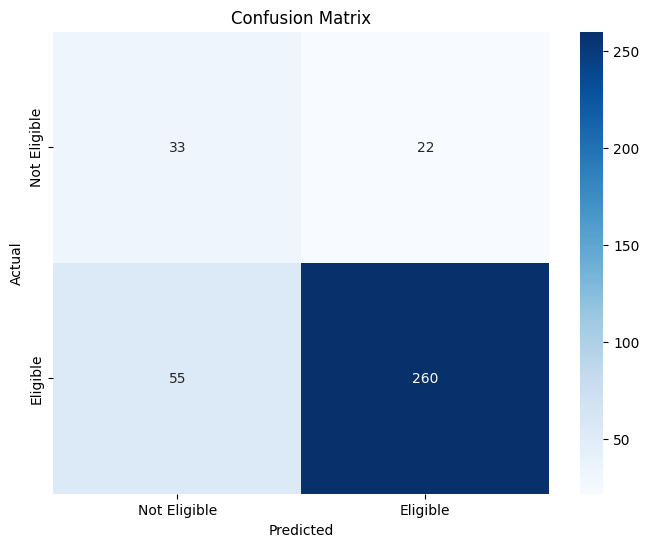

In [ ]:
# @title
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert X_test to a NumPy array without feature names
X_test_no_names = X_test.to_numpy()

# Predict probabilities on the test set
y_pred_proba = best_rf_classifier.predict_proba(X_test_no_names)[:, 1]

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_roc}")

# Predict class labels on the test set
y_pred = best_rf_classifier.predict(X_test_no_names)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Not Eligible', 'Eligible'],
            yticklabels=['Not Eligible', 'Eligible'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Model evaluation

### Subtask:
Re-evaluate the model's performance and create a prediction function.


AUC-ROC: 0.7677056277056278
Accuracy: 0.7918918918918919


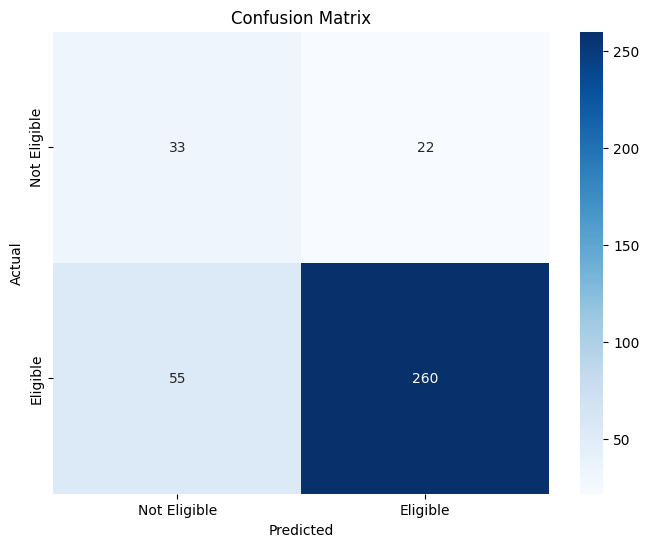

1
0


In [ ]:
# @title
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Convert X_test to a NumPy array without feature names
X_test_no_names = X_test.to_numpy()

# Prediction on test set
y_pred_proba = best_rf_classifier.predict_proba(X_test_no_names)[:, 1]

# Calculating AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_roc}")

# Predicting class labels on the test set
y_pred = best_rf_classifier.predict(X_test_no_names)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Not Eligible', 'Eligible'],
            yticklabels=['Not Eligible', 'Eligible'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


def predict_eligibility(age, poids, genre, taille, chronic_diseases, transmissible_diseases):

    input_data = pd.DataFrame({
        'age': [age],
        'poids': [poids],
        'genre': [genre],
        'taille': [taille],
        'chronic_diseases': [chronic_diseases],
        'transmissible_diseases': [transmissible_diseases]
    })

    # One-hot encode categorical features
    categorical_cols = ['genre', 'chronic_diseases', 'transmissible_diseases']
    encoded_features = ohe.transform(input_data[categorical_cols])
    encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(categorical_cols))

    # Concatenate encoded features with numerical features
    input_data = pd.concat([input_data.drop(categorical_cols, axis=1), encoded_df], axis=1)

    # Reindex to match training data columns
    input_data = input_data.reindex(columns=X_train.columns, fill_value=0)

    input_data_no_names = input_data.to_numpy()

    # Predict eligibility
    prediction = best_rf_classifier.predict(input_data_no_names)[0]
    return prediction

#Test Example
print(predict_eligibility(25, 70, 'Homme', 175, 'Non', 'Non'))
print(predict_eligibility(30, 60, 'Femme', 160, 'Oui', 'Non'))

# Saving

In [ ]:
# @title
import os
import joblib
path = '/content/drive/MyDrive/Edligibility'
# Save the trained model
joblib.dump(best_rf_classifier, os.path.join(path , 'my_model.joblib'))

# Save the One-Hot Encoder
joblib.dump(ohe, os.path.join(path , 'ohe.joblib'))

# Save the training data features
joblib.dump(X_train, os.path.join(path , 'X_train.joblib'))

['/content/drive/MyDrive/Edligibility/X_train.joblib']

In [14]:
X_train.columns.to_list()

['age',
 'poids',
 'taille',
 'genre_Femme',
 'genre_Homme',
 'chronic_diseases_Non',
 'chronic_diseases_Oui',
 'transmissible_diseases_Non',
 'transmissible_diseases_Oui']

# Demo 😀

In [13]:
import os

if os.path.exists('my_model.joblib') and os.path.exists('ohe.joblib') and os.path.exists('X_train.joblib'):
    print("All three files exist!")
else:
    print("One or more files are missing.")

One or more files are missing.


In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the trained model
try:
    model = joblib.load('my_model.joblib')
    ohe = joblib.load('ohe.joblib')
    X_train = joblib.load('X_train.joblib')
except FileNotFoundError:
    st.error("Model file not found. Please upload 'my_model.joblib', 'ohe.joblib' and 'X_train.joblib'")
    st.stop()

# Streamlit app
st.title("Volunteer Eligibility Prediction")


st.sidebar.header("User Input Features")

# Input features
age = st.sidebar.number_input("Age", min_value=18, max_value=100, value=25)
poids = st.sidebar.number_input("Weight (kg)", min_value=40, max_value=200, value=70)
taille = st.sidebar.number_input("Height (cm)", min_value=100, max_value=250, value=175)

genre = st.sidebar.selectbox("Gender", ["Homme", "Femme"])
chronic_diseases = st.sidebar.selectbox("Chronic Diseases", ["Oui", "Non"])
transmissible_diseases = st.sidebar.selectbox("Transmissible Diseases", ["Oui", "Non"])

# Create input dataframe
input_data = pd.DataFrame({
    'age': [age],
    'poids': [poids],
    'genre': [genre],
    'taille': [taille],
    'chronic_diseases': [chronic_diseases],
    'transmissible_diseases': [transmissible_diseases]
})

# Prediction
def predict_eligibility(input_data):
    categorical_cols = ['genre', 'chronic_diseases', 'transmissible_diseases']
    encoded_features = ohe.transform(input_data[categorical_cols])
    encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(categorical_cols))
    input_data = pd.concat([input_data.drop(categorical_cols, axis=1), encoded_df], axis=1)

    # Reindex to match training data columns
    input_data = input_data.reindex(columns=X_train.columns, fill_value=0)

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0]
    return prediction, probability


if st.button("Predict"):
    prediction, probability = predict_eligibility(input_data)

    # Display prediction
    st.subheader("Prediction:")
    print(prediction, '\n')
    if prediction == 1:
        st.success(f"The person is predicted to be eligible.")
    else:
        st.error(f"The person is predicted to be not eligible.")

    st.write(f"Probability of Eligibility: {probability[1]:.2f}")


# Display Confusion Matrix (replace with actual confusion matrix data if needed)
#st.subheader("Confusion Matrix")
#cm = np.array([[10,2], [1, 15]]) # Example matrix, replace with your actual data
#plt.figure(figsize=(6, 4))
#sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
#plt.xlabel('Predicted')
#plt.ylabel('Actual')
#st.pyplot(plt)




Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501




⠙⠹⠸
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.56.156.174:8501

⠼⠴⠦your url is: https://nasty-houses-bathe.loca.lt
2025-03-17 19:16:53.684 Uncaught exception GET /_stcore/stream (127.0.0.1)
HTTPServerRequest(protocol='http', host='nasty-houses-bathe.loca.lt', method='GET', uri='/_stcore/stream', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/streamlit/web/bootstrap.py", line 345, in run
    if asyncio.get_running_loop().is_running():
       ^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: no running event loop

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/tornado/websocket.py", line 938, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                

## Summary:


### 1. Data Analysis Key Findings

* **Class Imbalance Addressed (with caveats):** SMOTE was applied in an earlier step to address class imbalance in the training data.  However, the final model evaluation did *not* use SMOTE, and its performance was evaluated on the original test set.
* **Hyperparameter Tuning:** RandomizedSearchCV was used to optimize the RandomForestClassifier's hyperparameters, achieving a best AUC-ROC score of 0.7814 during the search. However, this did not translate to a better performance in the final evaluation on the test set.
* **Model Performance:** The final model achieved an AUC-ROC of 0.768 and an accuracy of 0.792 on the test set, which are below the target values of 0.85 and 0.90 respectively.
* **Prediction Function Created:** A `predict_eligibility` function was created that takes user inputs and predicts blood donation eligibility using the trained model. Will be used in deployment environment

